## 3 Data analysis

## Setup

### Load libraries

In [1]:
library(tidyverse)
library(plotrix)
library(RColorBrewer)
library(Hmisc)
library(patchwork)
library(zoo)
library(ggforce)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




### Set working directory

In [ ]:
wd <- "/path/to/03_image_analysis/04_axenic_migration"
setwd(wd)


### Set parameters

In [3]:
# Spatial scaling information (microns per pixel)
pixels_x <- 2049
physical_length_in_uM_x <- 1339.23
scale_factor_x <- physical_length_in_uM_x / pixels_x

pixels_y <- 3877
physical_length_in_uM_y <- 2534.59
scale_factor_y <- physical_length_in_uM_y / pixels_y

# Average pixel-to-micron scaling
scale_factor <- (scale_factor_x + scale_factor_y) / 2
scale_factor <- 0.654  # Overwrite with calibrated value if needed

# Time between frames in seconds
time_between_frames <- 0.5

### Define color palettes and strain mappings

In [14]:
wt_colors <- brewer.pal(n = 9, name = "Greens")
disfp_colors <- brewer.pal(n = 9, name = "Purples")
rescue_colors <- brewer.pal(n = 9, name = "Blues")

color_nr <- 6
strain_colors <- c("wt" = wt_colors[color_nr],
                   "ko" = disfp_colors[color_nr],
                   "re" = rescue_colors[color_nr])

color_nr_dark <- 9
strain_colors_dark <- c("wt" = wt_colors[color_nr_dark],
                        "ko" = disfp_colors[color_nr_dark],
                        "re" = rescue_colors[color_nr_dark])

strain_rename <- c(
  "ko" = expression(atop(italic(disfp)^"–", " mutant")),
  "re" = expression(atop(italic(disfp)^"–", " rescue")),
  "wt" = expression(atop("Ax2", "wildtype"))
)

strain_levels <- c("wt", "ko", "re")

### Load metadata

In [ ]:
# Define the file path
md_path <- file.path(wd, "02_data/tables/metadata.csv")

# Read the CSV into a dataframe
md <- read.csv(md_path, stringsAsFactors = FALSE)

### Load tracking data from CSVs


In [11]:
csv_folder_path <- file.path(wd, "02_data/trackmate/csv_combined")
csv_paths <- list.files(csv_folder_path, pattern = "\\.csv$", full.names = TRUE)

dataframes_list <- list()
for (path in csv_paths) {
  name <- tools::file_path_sans_ext(basename(path))
  dataframes_list[[name]] <- read.csv(path, header = TRUE, check.names = TRUE, sep = ",")
}


Split tables into spots, edges, and tracks


In [36]:
spots_df <- dataframes_list[["spots"]]
edges_df <- dataframes_list[["edges"]]
tracks_df <- dataframes_list[["tracks"]]

## Analysis

### Join metadata

In [37]:
edges_df <- edges_df %>%
  left_join(md, by = c("series" = "Series"))

In [47]:
max(edges_df$edge_time)

[1] 119.5

### Calculate mean speed per track and strain

In [38]:
edges_df_sum <- edges_df %>%
    group_by(Strain, track_id) %>% 
    summarise(mean_speed= mean(speed)) %>% 
    ungroup()

`summarise()` has grouped output by 'Strain'. You can override using the
`.groups` argument.


### Convert mean speed to µm/min

In [ ]:
edges_df_sum <- edges_df_sum %>%
  mutate(mean_speed_um_s = mean_speed * 0.32)

### Boxplot of mean cell speed

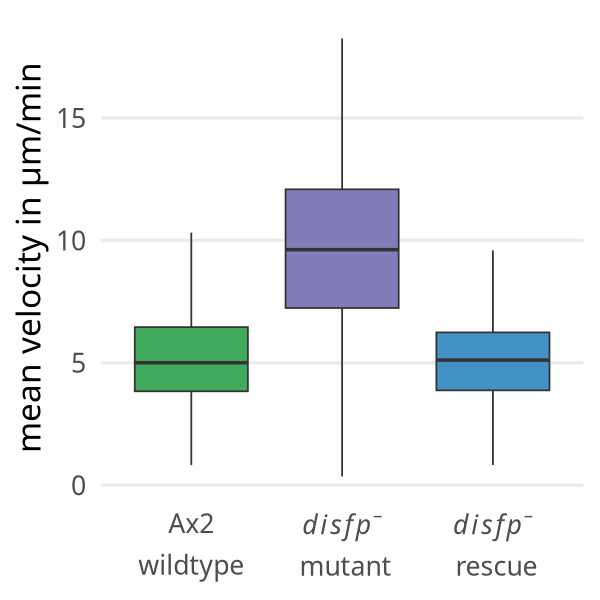

In [42]:
p_speed_boxplot <- edges_df_sum %>%
  mutate(Strain = factor(Strain, levels = strain_levels)) %>%
  ggplot(aes(x = Strain, y = mean_speed_um_s, fill = Strain)) +
  geom_boxplot(alpha = 1, outlier.shape = NA, outliers = FALSE) +
  scale_fill_manual(values = strain_colors) +
  scale_x_discrete(labels = strain_rename) +
  labs(x = NULL, y = "mean velocity in µm/min") +
  theme_minimal(base_size = 20) +
  guides(fill = FALSE) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    strip.text.x = element_text(color = "black", face = "bold"),
    strip.background = element_rect(colour = "white", fill = "white", size = NA, linetype = "solid")
  )

options(repr.plot.width = 5, repr.plot.height = 5)
p_speed_boxplot